1. 圆形截面：最标准的计算 (Circular Sections)。计算项目实心圆轴 

|计算项目|实心圆轴 (Solid)|空心圆轴 (Hollow)|
|:-- |:--  |:-- |
|极惯性矩 J|$J = \frac{\pi d^4}{32}$|​$J = \frac{\pi (d_o^4 - d_i^4)}{32}$​|
|最大剪应力 $\tau_{max}$|​$\tau_{max}=\frac{16T}{\pi d^3}$​ |$\tau_{max} = \frac{16T d_o}{\pi (d_o^4 - d_i^4)}$​​|
|扭转角 θ (rad)|$\theta=\frac{GJ}{TL}$ | $\theta=\frac{GJ}{TL}$|​

- where G is the shear module

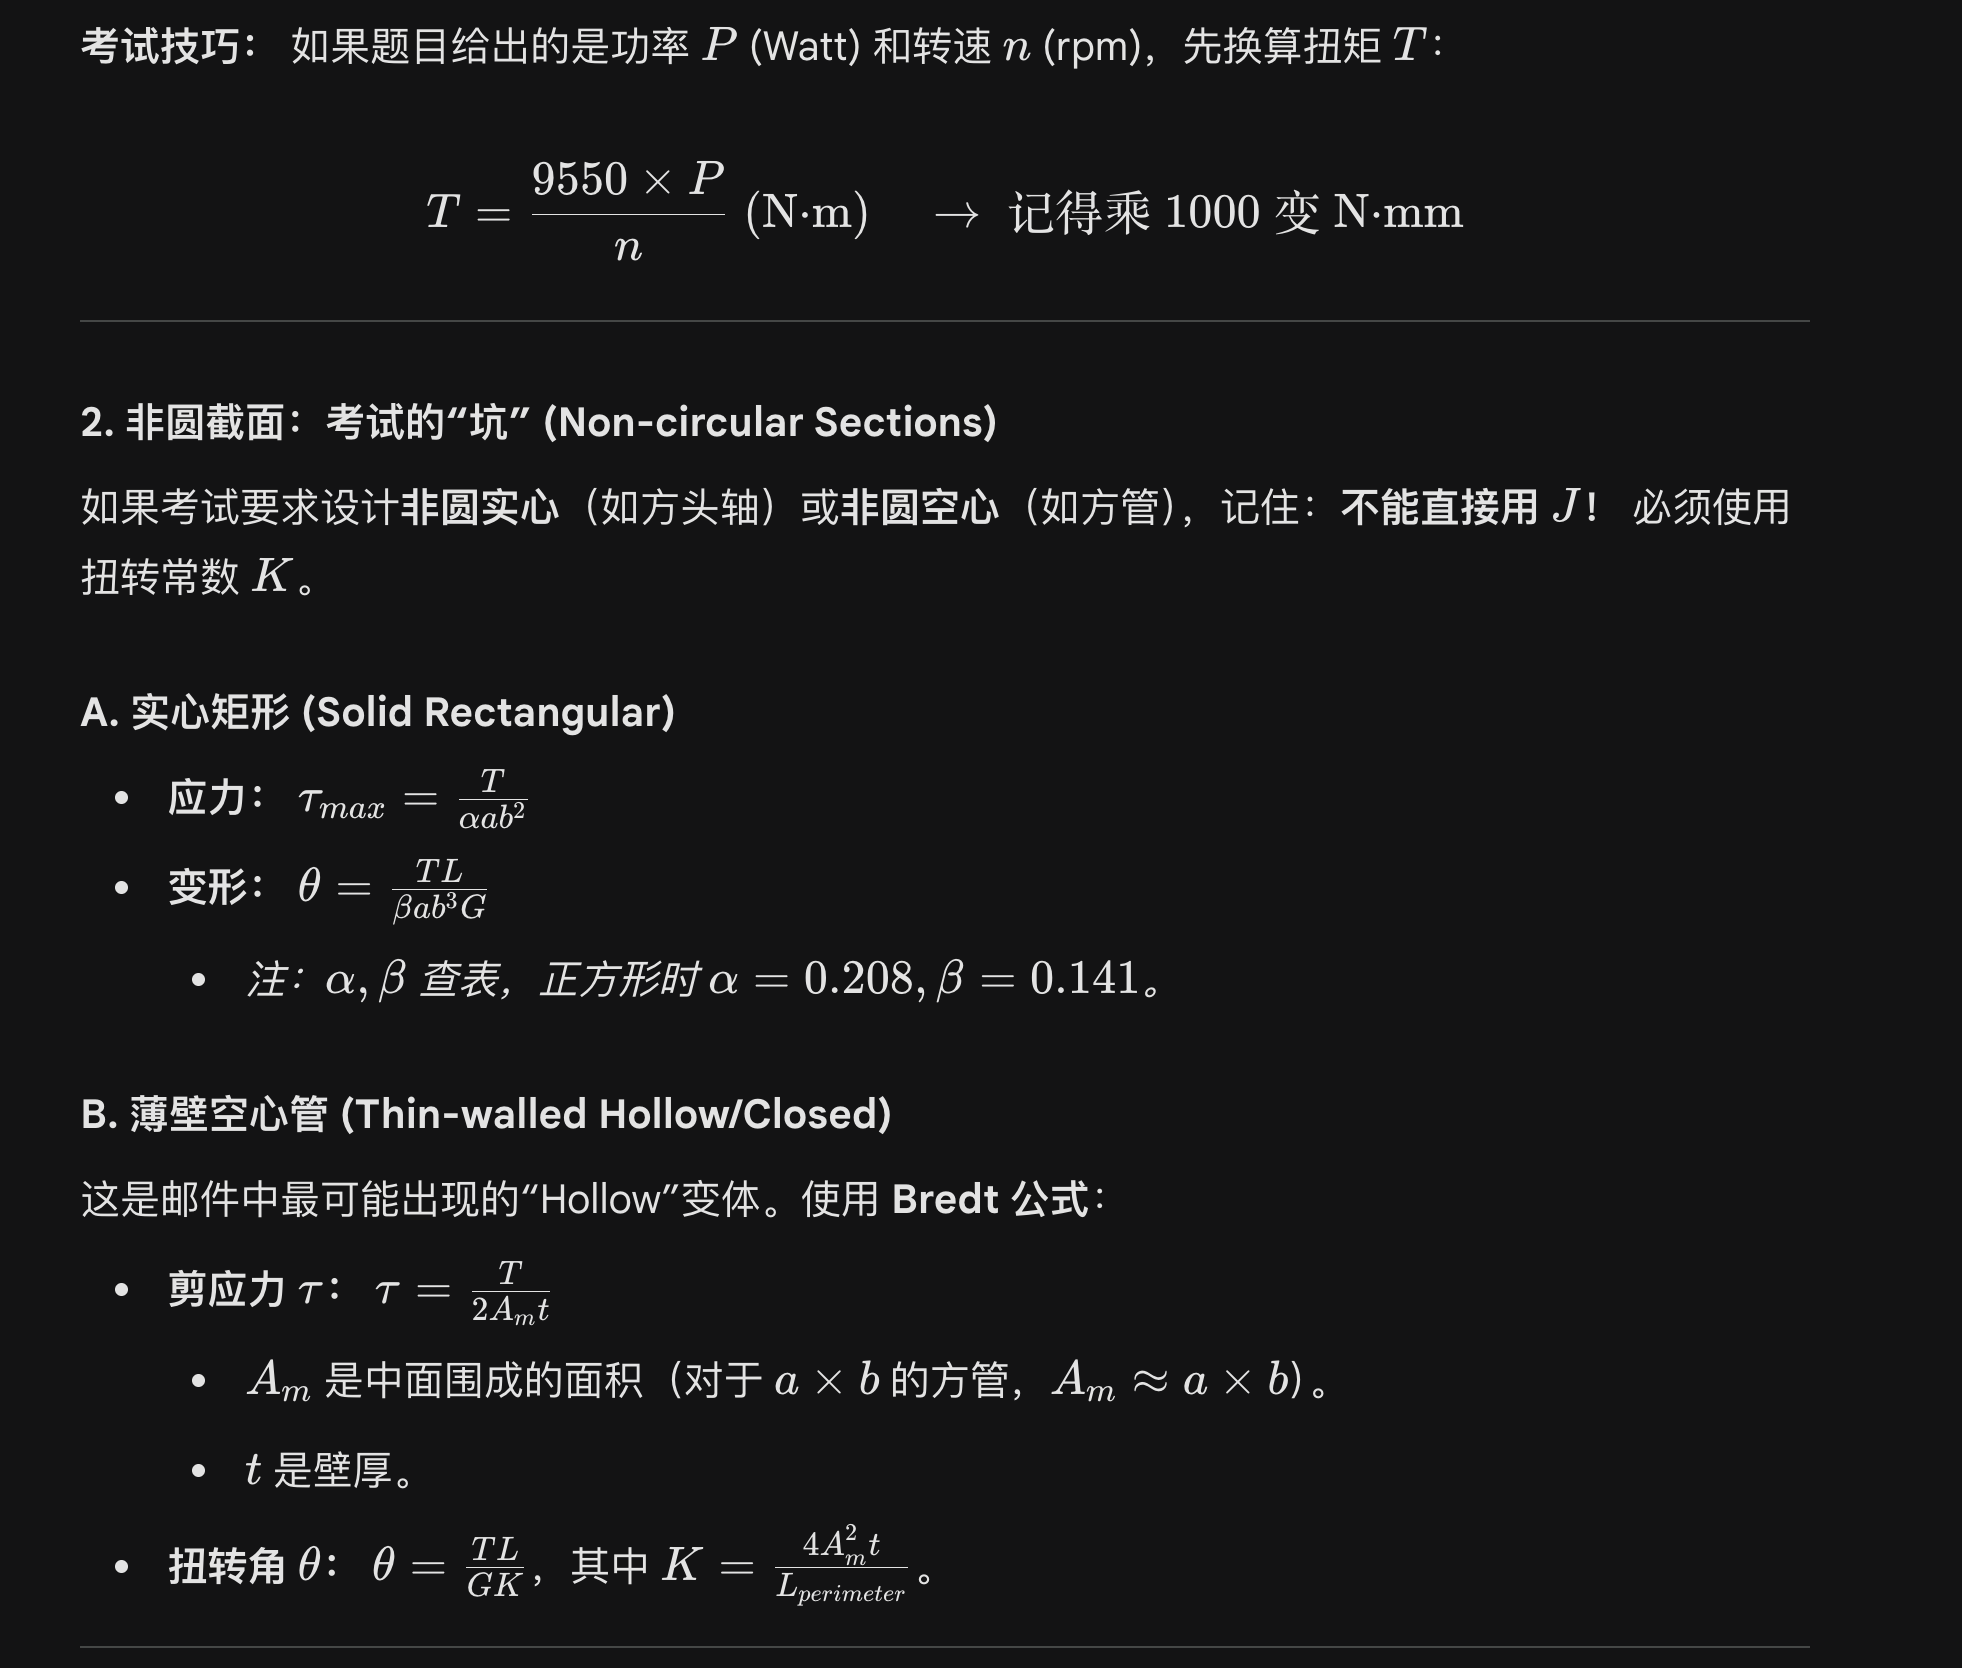

1. 题目要求“Weight Reduction”（减重）时： 毫不犹豫选 Hollow Circular。
2. 出现“Warping”（翘曲）这个词时： 说明你在处理非圆截面，检查 $\theta$ 时要小心。
3. 求安全系数 $n$ 时： * 对于扭转，$S_{sy} = 0.577 S_y$ (根据畸变能理论)。$n = \frac{S_{sy}}{\tau_{max}}$。
4. 注意轴向定位： 空心轴通常不能直接车阶梯轴肩，可能需要配合紧定衬套 (Adapter Sleeves) 或焊接法兰。

关键提醒： 邮件里既然提到了受扭构件的应力和挠度计算，单位单位单位！ 务必统一到 $N, mm, MPa$。如果算出的 $\theta$ 单位是 rad，记得乘 $180/\pi$ 转换成度，因为规范通常规定 $1^\circ$ 以内为合格。

In [1]:
import math

def torsion_analysis(T_nm, L_mm, material_G_pa=79e9):
    T = T_nm * 1000  # 换算为 N·mm
    G = material_G_pa / 1000 # 换算为 MPa
    
    # 方案1: 实心圆轴 d=30mm
    d_solid = 30
    J_s = (math.pi * d_solid**4) / 32
    tau_s = (16 * T) / (math.pi * d_solid**3)
    theta_s = (T * L_mm) / (G * J_s)
    
    # 方案2: 空心圆轴 do=30mm, di=20mm
    do, di = 30, 20
    J_h = (math.pi * (do**4 - di**4)) / 32
    tau_h = (16 * T * do) / (math.pi * (do**4 - di**4))
    theta_h = (T * L_mm) / (G * J_h)
    
    print(f"实心轴: 应力={tau_s:.2f} MPa, 扭转角={math.degrees(theta_s):.4f} deg")
    print(f"空心轴: 应力={tau_h:.2f} MPa, 扭转角={math.degrees(theta_h):.4f} deg")
    print(f"重量节省: { (di/do)**2 * 100 :.1f}%")

# 示例：100Nm扭矩，500mm长轴
torsion_analysis(100, 500)

实心轴: 应力=18.86 MPa, 扭转角=0.0005 deg
空心轴: 应力=23.51 MPa, 扭转角=0.0006 deg
重量节省: 44.4%


挠度图已生成。


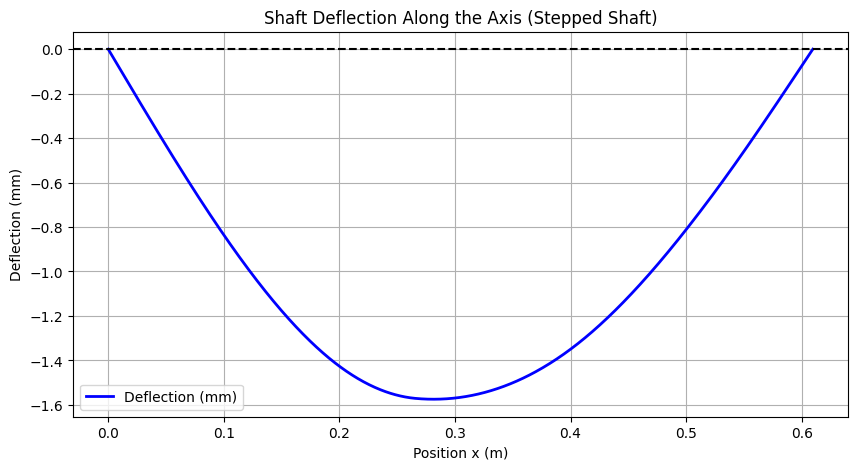

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 输入参数 (根据你的设计修改)
# ==========================================
L = 0.6096          # 轴总长 (m)
E = 205e9           # 弹性模量 (Pa)
RA = 7117.3         # 左支座反力 (N)
F1 = 5337.9         # 载荷1 (N)
pos_F1 = 0.2032     # 载荷1位置 (m)
F2 = 10676.0        # 载荷2 (N)
pos_F2 = 0.4064     # 载荷2位置 (m)

# 定义直径的变化点和对应的直径 (m) [cite: 169, 194, 224]
# 这里的逻辑是：在哪些位置直径发生了变化
x_breaks = [0, 0.2667, 0.5207, 0.6096] 
d_values = [0.041275, 0.047625, 0.044450] # 每一段的直径

# ==========================================
# 2. 计算过程 (自动运行)
# ==========================================
# 将轴细分为 1000 个微小单元
n_points = 1000
x = np.linspace(0, L, n_points)
dx = L / (n_points - 1)

# A. 计算每一点的弯矩 M(x)
M = np.zeros(n_points)
for i, xi in enumerate(x):
    # 弯矩 = 支反力矩 - 各个载荷力矩
    m = RA * xi
    if xi > pos_F1: m -= F1 * (xi - pos_F1)
    if xi > pos_F2: m -= F2 * (xi - pos_F2)
    M[i] = m

# B. 计算每一点的惯性矩 I(x) [cite: 170]
I = np.zeros(n_points)
for i, xi in enumerate(x):
    # 根据当前位置 xi 判断属于哪一段直径
    idx = 0
    for j in range(len(x_breaks)-1):
        if x_breaks[j] <= xi <= x_breaks[j+1]:
            idx = j
            break
    I[i] = np.pi * (d_values[idx]**4) / 64

# C. 计算曲率 (M / EI)
curvature = M / (E * I)

# D. 第一次数值积分：求斜率 (Slope)
# 注意：积分会产生常数，我们先假设初始斜率为0
slope_raw = np.cumsum(curvature) * dx

# E. 第二次数值积分：求挠度 (Deflection)
# 同样先假设初始挠度为0
v_raw = np.cumsum(slope_raw) * dx

# F. 修正边界条件 (Boundary Conditions) 
# 真正的挠度 v 在两个支座处(x=0 和 x=L)必须为 0
# 我们通过线性修正，把倾斜的 v_raw 拉平
v_final = v_raw - (v_raw[0] + (x / L) * (v_raw[-1] - v_raw[0]))

# ==========================================
# 3. 绘图 (Plot)
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(x, v_final * 1000, label='Deflection (mm)', color='blue', lw=2)
plt.axhline(0, color='black', linestyle='--')
plt.title("Shaft Deflection Along the Axis (Stepped Shaft)")
plt.xlabel("Position x (m)")
plt.ylabel("Deflection (mm)")
plt.grid(True)
plt.legend()
plt.savefig('stepped_shaft_deflection.png')
print("挠度图已生成。")